# 02 — Model Training: YOLO26 Nano
### GreenFlow Rabat · Edge AI Traffic Management

**Goal of this notebook:** Train a lightweight object detection model that can identify 8 Moroccan traffic classes in real-time on edge hardware (Raspberry Pi / basic laptop).

---

### 🗺️ Notebook Roadmap

| Step | What we do | Why |
|------|-----------|-----|
| **1** | Understand YOLO26 architecture | Know *what* you're training before you train it |
| **2** | Environment & hardware check | Confirm GPU is available (CPU = hours, GPU = minutes) |
| **3** | Load & validate the dataset | Catch path/class errors *before* wasting a training run |
| **4** | Configure hyperparameters | Each setting has a purpose — we'll explain every one |
| **5** | Launch training | The actual `model.train()` call |
| **6** | Analyze results | Read the metrics, understand what the model learned |
| **7** | Export for edge deployment | Convert `.pt` → ONNX / OpenVINO for real-time inference |

**Philosophy:** We build understanding first, then code. Every cell earns its place.

## Step 1: Understanding the YOLO26 Architecture

Before writing a single line of training code, let's understand **what** YOLO26 actually does differently — and why it matters for our traffic project.

---

### The Big Picture: How Any YOLO Model Works

Every YOLO model has **3 main parts**, like a factory assembly line:

```
+--------------+     +---------------+     +---------------+
|  BACKBONE    | --> |    NECK       | --> |    HEAD       |
|              |     |               |     |               |
| "The Eyes"   |     | "The Brain"   |     | "The Mouth"   |
| Extracts     |     | Mixes info    |     | Outputs       |
| features     |     | from all      |     | boxes +       |
| from pixels  |     | scales        |     | classes       |
+--------------+     +---------------+     +---------------+
```

- **Backbone** looks at the raw image and extracts patterns (edges, then shapes, then objects).
- **Neck** combines features from different scales (so we can detect both a tiny moto far away AND a huge bus close up).
- **Head** makes the final prediction: "There's a Grand Taxi at coordinates (x, y, w, h) with 92% confidence."

---

### What Makes YOLO26 Different from YOLOv8/v11?

#### 1. NMS-Free Detection (The Biggest Change)

**The old way (YOLOv8, v11):**
```
Image --> Model predicts 8,400 boxes --> NMS removes 8,350 duplicates --> ~50 final detections
```
NMS (Non-Maximum Suppression) is a slow, sequential CPU algorithm. In a dense Rabat intersection with 30+ vehicles, NMS becomes a **bottleneck** — especially on a Raspberry Pi.

**The YOLO26 way:**
```
Image --> Model predicts ~50 boxes directly --> Done. No post-processing.
```
YOLO26 uses **one-to-one matching** during training: each ground-truth object is assigned to exactly ONE prediction. The model learns to output clean results natively.

**Why this matters for GreenFlow:** At a busy Rabat intersection, we need consistent ~30 FPS on edge hardware. Eliminating NMS saves 5-15ms per frame — that's the difference between real-time and laggy.

---

#### 2. Large-Kernel Attention (Better "Peripheral Vision")

Standard convolutions see a small 3x3 pixel window at a time. To understand that a distant speck of light is an ambulance (not a streetlamp), the model needs **global context**.

YOLO26 uses **large-kernel depthwise convolutions** (7x7 or larger) combined with attention mechanisms. Think of it as giving the model "peripheral vision" — it can look at a wider area to make smarter decisions.

**Why this matters for GreenFlow:** Night scenes with headlight glare. Rain reflections. A tram that spans half the image. Large-kernel attention handles all of these better.

---

#### 3. Efficient Backbone Design

YOLO26 redesigns the backbone with **reparameterizable blocks** — during training, the model uses a complex multi-branch structure for accuracy, but at export time, these branches are **mathematically fused** into a single, fast convolution.

```
Training:  Branch A --+
           Branch B ---+--> Fused into ONE convolution at export
           Branch C --+

Inference: Just ONE fast convolution (same accuracy, 3x fewer operations)
```

**Why this matters for GreenFlow:** We get training-grade accuracy with inference-grade speed. The exported model is lighter than what we trained.

---

### YOLO26n vs YOLOv8n vs YOLO11n — At a Glance

| Metric | YOLOv8n | YOLO11n | **YOLO26n** |
|--------|---------|---------|-------------|
| Parameters | 3.2M | 2.6M | ~2.5M |
| NMS required | Yes | Yes | **No** |
| Post-processing | ~10ms on CPU | ~10ms on CPU | **~0ms** |
| Small object accuracy | Good | Better | **Best** |
| Edge export | Custom NMS ops needed | Custom NMS ops needed | **Clean graph** |

---

### Our Choice: `yolo26n.pt` (Nano)

We use the **Nano** variant because:
- It's the smallest (fewest parameters = fastest inference)
- Our 8 classes are visually distinct (we don't need a huge model to tell a tram from a moto)
- Edge deployment demands it — a Raspberry Pi can't run the Large variant

**Next:** Let's set up the environment and verify we have GPU access.

## Step 2: Environment Setup

We need exactly **two** packages:
- **ultralytics** — the official YOLO library (provides YOLO26, data loading, training loop, metrics, export — everything)
- **torch (PyTorch)** — the deep learning engine under the hood (usually pre-installed on Colab/Kaggle)

That's it. No scikit-learn, no TensorFlow, no custom code. Ultralytics handles the entire pipeline.

In [1]:
# ---------- Install Ultralytics ----------
# Why "upgrade"? YOLO26 is brand new — we need the latest version
# that includes the yolo26n.pt weights. Older versions don't have it.
#
# Why subprocess instead of !pip? This works on ANY platform
# (Colab, Kaggle, local machine, Paperspace) — no magic syntax.

import subprocess, sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "ultralytics"],
    stdout=subprocess.DEVNULL
)

# Verify the installed version
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
print("If version >= 8.3.x, YOLO26 is supported.")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\CE PC\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.21
If version >= 8.3.x, YOLO26 is supported.


In [5]:
# ---------- Hardware Check ----------
# WHY THIS MATTERS:
# - GPU training:  ~15 min for 50 epochs on 6,294 images
# - CPU training:  ~8-12 HOURS for the same job
#
# If you see "CUDA: False", go to Runtime > Change runtime type > GPU (T4)
# On Kaggle: Settings > Accelerator > GPU T4 x2

import torch
import platform

print("=" * 50)
print("  GreenFlow Rabat — Hardware Report")
print("=" * 50)
print(f"  Python  :  {platform.python_version()}")
print(f"  PyTorch :  {torch.__version__}")
print(f"  CUDA    :  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU     :  {gpu_name}")
    print(f"  VRAM    :  {vram_gb:.1f} GB")
    
    # Batch size recommendation based on VRAM
    # yolo26n uses ~1.2 GB base + ~0.3 GB per batch image at 640x640
    max_batch = int((vram_gb - 1.5) / 0.3)
    recommended = min(max_batch, 32)  # Cap at 32 (diminishing returns above this)
    print(f"  Recommended batch size: {recommended}")
else:
    print("  GPU     :  None (CPU mode)")
    print("  WARNING :  Training will be VERY slow on CPU.")
    print("  ACTION  :  Switch to GPU runtime before proceeding.")

print("=" * 50)

  GreenFlow Rabat — Hardware Report
  Python  :  3.12.12
  PyTorch :  2.10.0+cpu
  CUDA    :  False
  GPU     :  None (CPU mode)
  ACTION  :  Switch to GPU runtime before proceeding.


## Step 3: Load & Validate the Dataset

Before training, we **must** verify 3 things:
1. **Paths** — Does `data.yaml` actually point to real folders?
2. **Labels** — Do the `.txt` files contain valid annotations?
3. **Class balance** — How skewed is our data? (This tells us if we need special handling)

**Why bother?** The #1 cause of failed YOLO training runs is a wrong path in `data.yaml`. A 50-epoch training run takes ~15 minutes on GPU — you don't want to discover the path was wrong at epoch 49.

---

### 📂 Setup for Google Colab

**Step 1 — Create a zip file locally** (run this ONCE in your project folder):
```
cd "C:\Users\CE PC\GreenFlow_Rabat"
python zip_dataset.py
```
This creates `dataset.zip` (~352 MB) containing `data.yaml` + `train/` + `valid/` + `test/`.

**Step 2 — Upload `dataset.zip` to Google Drive:**
```
My Drive/
  GreenFlow-Rabat/          ← folder name with HYPHEN
    dataset.zip             ← just this ONE file (~30s to extract vs 15min for raw files)
```

**Why zip?** Google Drive is network-mounted. Copying 12,000+ individual files takes 10-20 minutes. Extracting one zip takes ~30 seconds. Same data, 20x faster.

The cell below will:
1. Mount Google Drive
2. Extract `dataset.zip` to Colab's local SSD (`/content/dataset/`)
3. Validate all paths and classes
4. On re-runs, skip extraction if data already exists

In [ ]:
# ---------- Validate data.yaml ----------
# ENVIRONMENT HANDLING:
#   Google Colab → Mount Drive, unzip dataset to local SSD, validate
#   Kaggle → Find dataset in /kaggle/input (auto-extracted by Kaggle)
#   VS Code local → Find data.yaml relative to CWD, validate

import yaml, os, shutil, zipfile, time
from pathlib import Path

# ---- Detect environment ----
ON_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    # ============================================================
    #  KAGGLE — Data is automatically extracted in /kaggle/input
    # ============================================================
    print("  Detected environment: KAGGLE")
    kaggle_input = Path("/kaggle/input")
    
    # Kaggle unzips uploaded files automatically. We just need to find data.yaml
    yaml_candidates = list(kaggle_input.rglob("data.yaml"))
    
    if not yaml_candidates:
        raise FileNotFoundError(
            f"Cannot find data.yaml in Kaggle inputs!\n"
            f"  Please click '+ Add Data' (top right) > 'Upload' \n"
            f"  and upload your dataset.zip file."
        )
        
    YAML_PATH = yaml_candidates[0]
    PROJECT_ROOT = YAML_PATH.parent

elif ON_COLAB:
    # ============================================================
    #  GOOGLE COLAB — Mount Drive & extract dataset to local SSD
    # ============================================================
    print("  Detected environment: GOOGLE COLAB")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DRIVE_FOLDER = Path("/content/drive/MyDrive/GreenFlow-Rabat")
    LOCAL_DATASET = Path("/content/dataset")

    if LOCAL_DATASET.exists() and (LOCAL_DATASET / "data.yaml").exists():
        print("  Dataset already on SSD. Skipping extraction.")
    else:
        ZIP_PATH = DRIVE_FOLDER / "dataset.zip"
        if ZIP_PATH.exists():
            LOCAL_DATASET.mkdir(parents=True, exist_ok=True)
            print(f"  Extracting {ZIP_PATH.name} ...")
            with zipfile.ZipFile(str(ZIP_PATH), "r") as zf:
                zf.extractall(str(LOCAL_DATASET))
        else:
            raise FileNotFoundError("Dataset not found on Google Drive!")

    YAML_PATH = LOCAL_DATASET / "data.yaml"
    PROJECT_ROOT = LOCAL_DATASET

else:
    # ============================================================
    #  LOCAL (VS Code) — Find data.yaml relative to CWD
    # ============================================================
    print("  Detected environment: LOCAL (VS Code)")
    candidates = [Path("data.yaml"), Path("../data.yaml")]

    YAML_PATH = None
    for c in candidates:
        if c.exists():
            YAML_PATH = c.resolve()
            break

    if YAML_PATH is None:
        raise FileNotFoundError("Cannot find data.yaml!")

    PROJECT_ROOT = YAML_PATH.parent

# ---- Parse the YAML and Verify ----
print(f"\n  data.yaml : {YAML_PATH}")
print(f"  Project root : {PROJECT_ROOT}\n")

with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

print("=" * 55)
print("  PATH VALIDATION")
print("=" * 55)

all_ok = True
for split_key in ["train", "val", "test"]:
    if split_key not in data_cfg: continue
    
    raw_path = data_cfg[split_key]
    full_path = (PROJECT_ROOT / raw_path).resolve()
    exists = full_path.exists()
    
    count = len(list(full_path.iterdir())) if exists else 0
    status = f"OK ({count} files)" if exists else "MISSING!"
    if not exists: all_ok = False

    print(f"  {split_key:6s}: {raw_path:25s} -> {status}")

print(f"\n  Classes (nc={data_cfg['nc']}): {data_cfg['names']}")
if all_ok:
    print(f"\n  All paths verified. Dataset is ready for training!")
else:
    print(f"\n  PROBLEM: Some paths are missing.")

Mounted at /content/drive
  Found dataset.zip — extracting to local SSD ...
  Extracted in 11s

  data.yaml : /content/dataset/data.yaml
  Project root : /content/dataset

  PATH VALIDATION
  train : ./train/images            -> OK (4406 files)
  val   : ./valid/images            -> OK (1259 files)
  test  : ./test/images             -> OK (629 files)

  Classes (nc=8): ['Grand Taxi', 'Triporteur', 'bus', 'camion', 'moto', 'tram', 'urgence', 'voiture']

  All paths verified. Dataset is ready for training!


  CLASS DISTRIBUTION
  Annotated images: 1,088
  Empty images (negative samples): 5,206
  Total bounding boxes: 7,914

  0: Grand Taxi          168  (  2.1%)  ##
  1: Triporteur           11  (  0.1%)  
  2: bus                 190  (  2.4%)  ##
  3: camion              214  (  2.7%)  ##
  4: moto                203  (  2.6%)  ##
  5: tram                 12  (  0.2%)  
  6: urgence               7  (  0.1%)  
  7: voiture           7,109  ( 89.8%)  #########################################################################################


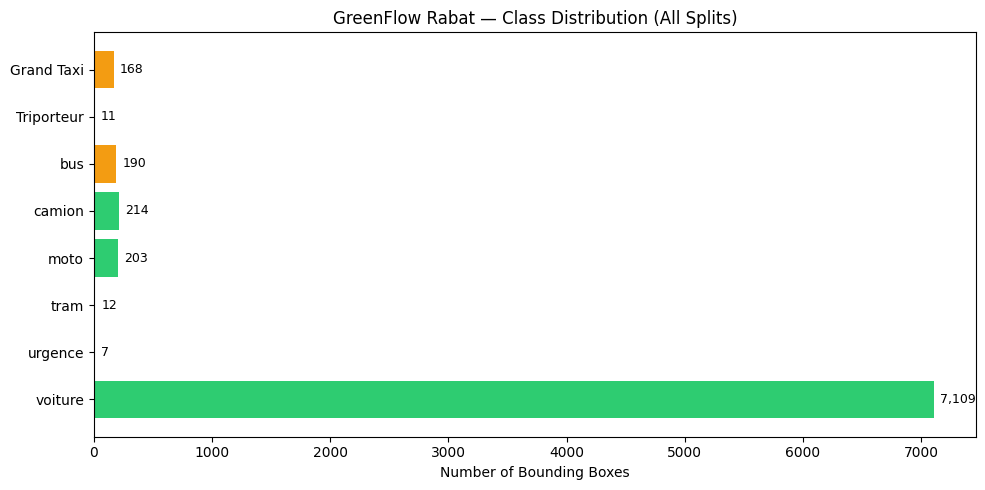


  Largest class has 1016x more boxes than smallest (urgence: 7).
  We will address this in Step 4 with hyperparameter tuning.


In [ ]:
# ---------- Class Distribution ----------
# WHY THIS MATTERS:
# If 90% of your bounding boxes are "voiture" and only 0.1% are "urgence",
# the model will learn to detect cars perfectly but IGNORE ambulances.
# We need to SEE the imbalance before deciding how to handle it.

from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

class_names = data_cfg["names"]  # ['Grand Taxi', 'Triporteur', 'bus', ...]
class_counts = Counter()
annotated_files = 0
empty_files = 0

# Count every bounding box across all splits
# Check both "valid" and "val" folder names (Roboflow uses "valid", some tools use "val")
for split in ["train", "valid", "val", "test"]:
    label_dir = PROJECT_ROOT / split / "labels"
    if not label_dir.exists():
        continue
    for label_file in label_dir.glob("*.txt"):
        text = label_file.read_text().strip()
        if text:
            annotated_files += 1
            for line in text.splitlines():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
        else:
            empty_files += 1

total_boxes = sum(class_counts.values())

# Print summary
print("=" * 55)
print("  CLASS DISTRIBUTION (V2 — Clean Moroccan Dataset)")
print("  Split: 70% train / 20% valid / 10% test")
print("=" * 55)
print(f"  Annotated images: {annotated_files:,}")
print(f"  Empty images (negative samples): {empty_files:,}")
print(f"  Total bounding boxes: {total_boxes:,}\n")

for idx in range(len(class_names)):
    count = class_counts.get(idx, 0)
    pct = (count / total_boxes * 100) if total_boxes > 0 else 0
    bar = "#" * int(pct)  # Simple text bar
    print(f"  {idx}: {class_names[idx]:15s}  {count:>6,}  ({pct:5.1f}%)  {bar}")

# ---- Visual bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts.get(i, 0) for i in range(len(class_names))]
colors = ['#e74c3c' if c < 50 else '#f39c12' if c < 200 else '#2ecc71' for c in counts]
# Red = dangerously low, Orange = low, Green = healthy

bars = ax.barh(class_names, counts, color=colors)
ax.set_xlabel("Number of Bounding Boxes")
ax.set_title("GreenFlow Rabat V2 — Class Distribution (All Splits)")
ax.invert_yaxis()  # Largest class at top

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Warning if severe imbalance ----
if class_counts:
    min_class = class_names[min(class_counts, key=class_counts.get)]
    min_count = min(class_counts.values())
    max_count = max(class_counts.values())
    ratio = max_count / min_count if min_count > 0 else float('inf')

    if ratio > 50:
        print(f"\n  WARNING: Severe class imbalance detected!")
        print(f"  Largest class has {ratio:.0f}x more boxes than smallest ({min_class}: {min_count}).")
        print(f"  V2 addresses this with: image_weights=True, fl_gamma=2.0, copy_paste=0.5")

## Step 4: Hyperparameter Configuration (V2 — Clean Moroccan Dataset)

### What changed from V1?

| Aspect | V1 | V2 | Why |
|--------|----|----|-----|
| **Dataset** | ~5,000 images (4,000+ foreign/unannotated) | ~1,000 pure Moroccan annotated images | Eliminated domain shift and background poisoning |
| **Epochs** | 100 | **300** | Smaller dataset needs more passes for rare classes |
| **Patience** | 15 | **45** | Rare classes emerge late — don't stop too early |
| **Copy-Paste** | 0.3 | **0.5** | More aggressive synthetic injection of rare classes |
| **Image Weights** | off | **True** | Oversample images containing rare classes |
| **Focal Loss** | off | **fl_gamma=2.0** | Downweight easy "voiture" detections, focus on hard classes |
| **Warmup** | default | **5.0 epochs** | Gentle start prevents gradient explosions on small data |

---

### Problem 1: Severe Class Imbalance (Still Present)

Even with the cleaned dataset, `voiture` dominates. The V2 strategy uses **4 independent weapons** to fight this:

| Strategy | How it helps | Parameter |
|----------|-------------|-----------|
| **Copy-Paste 0.5** | Pastes rare objects onto other images at 50% probability — strongest synthetic augmentation | `copy_paste=0.5` |
| **Image Weights** | During batch sampling, images containing rare classes are picked MORE OFTEN | `image_weights=True` |
| **Focal Loss γ=2.0** | Reduces loss contribution from easy/confident predictions (voiture), amplifies loss from hard ones (urgence) | `fl_gamma=2.0` |
| **Mosaic + MixUp** | Mosaic stitches 4 images (rare + common mix), MixUp blends 2 images (forces robust features) | `mosaic=1.0`, `mixup=0.15` |

#### How these 4 weapons work together

```
Step 1 — Image Weights:    Pick images WITH rare objects more often
Step 2 — Mosaic:           Stitch 4 picked images → rare + common appear together
Step 3 — Copy-Paste 0.5:   Paste extra rare objects INTO the mosaic
Step 4 — Focal Loss:       When computing loss, PENALIZE the model more for
                           missing rare objects vs. missing common ones
```

---

### Problem 2: Small Dataset (~1,000 images)

With fewer images, overfitting is a real risk. Our defenses:

| Strategy | How it helps |
|----------|-------------|
| **Transfer Learning** | Start from COCO pretrained weights (330K images already learned) |
| **Heavy Augmentation** | Mosaic + MixUp + CopyPaste + color jitter = each image appears in thousands of unique combinations |
| **Cosine LR + Long Warmup** | Gentle start (5 epochs), then smooth decay — prevents memorizing early batches |
| **Weight Decay** | L2 regularization penalizes large weights that overfit to training data |
| **Early Stopping** | patience=45 — if no real improvement after 45 epochs, stop and keep best weights |

---

### Hyperparameter Reference Table (V2)

| Parameter | V1 | **V2** | Why changed |
|-----------|----|----|-------------|
| `model` | `yolo26n.pt` | `yolo26n.pt` | Same — Nano for edge deployment |
| `epochs` | 100 | **300** | Small dataset needs more passes |
| `patience` | 15 | **45** | Rare classes emerge late in training |
| `batch` | 16 | 16 | Safe for Kaggle P100 (16 GB VRAM) |
| `imgsz` | 640 | 640 | Standard YOLO input size |
| `optimizer` | AdamW | AdamW | Still best for small/imbalanced datasets |
| `lr0` | 0.001 | 0.001 | — |
| `lrf` | 0.01 | 0.01 | — |
| `cos_lr` | True | True | — |
| `warmup_epochs` | default | **5.0** | Stabilize gradients on small data |
| `mosaic` | 1.0 | 1.0 | — |
| `mixup` | 0.15 | 0.15 | — |
| `copy_paste` | 0.3 | **0.5** | Stronger rare-class injection |
| `image_weights` | — | **True** | Oversample rare-class images |
| `fl_gamma` | — | **2.0** | Focal loss for hard examples |
| `name` | greenflow_v1 | **greenflow_v2** | New experiment |

In [ ]:
# ---------- V2 Hyperparameter Configuration ----------
# WHAT CHANGED FROM V1:
#   - Dataset: Purged ~4,000 foreign/unannotated images → pure Moroccan data only
#   - epochs: 100 → 300 (smaller dataset needs more passes)
#   - patience: 15 → 45 (rare classes need time to emerge)
#   - copy_paste: 0.3 → 0.5 (more aggressive rare-class injection)
#   - warmup_epochs: NEW — gentle start prevents early gradient explosions
#   - name: greenflow_v1 → greenflow_v2

from ultralytics import YOLO

# ---- Load pretrained YOLO26 Nano ----
model = YOLO("yolo26n.pt")

print(f"  Model loaded: yolo26n.pt")
print(f"  Parameters: {sum(p.numel() for p in model.model.parameters()):,}")
print(f"  Pretrained on: COCO (80 classes)")
print(f"  Fine-tuning to: {data_cfg['nc']} classes ({data_cfg['names']})")

# ---- Training hyperparameters (V2 — optimized for clean Moroccan dataset) ----
TRAIN_ARGS = dict(
    # === DATA ===
    data      = str(YAML_PATH),       # Path to our data.yaml
    imgsz     = 640,                   # Input resolution (matches Roboflow resize)

    # === TRAINING SCHEDULE ===
    epochs    = 300,                   # V2: more epochs — small dataset needs more passes
    patience  = 45,                    # V2: longer patience — rare classes emerge late
    batch     = 16,                    # Images per batch (16 is safe for P100 16GB)

    # === OPTIMIZER ===
    optimizer = "AdamW",               # Better than SGD for small/imbalanced datasets
    lr0       = 0.001,                 # Initial learning rate
    lrf       = 0.01,                  # Final LR = 1% of lr0
    cos_lr    = True,                  # Cosine annealing: smooth LR decay
    weight_decay = 0.0005,             # L2 regularization (prevents overfitting)
    warmup_epochs = 5.0,               # V2: gentle 5-epoch warmup to stabilize gradients

    # === AUGMENTATION (V2: more aggressive anti-imbalance) ===
    mosaic    = 1.0,                   # Stitch 4 images → rare objects mix with common ones
    mixup     = 0.15,                  # Blend 2 images → forces robust feature learning
    copy_paste = 0.5,                  # V2: 0.3→0.5 — stronger rare-class injection
    hsv_h     = 0.015,                 # Hue jitter (lighting variation)
    hsv_s     = 0.7,                   # Saturation jitter (color richness)
    hsv_v     = 0.4,                   # Value/brightness jitter (day/night)
    degrees   = 5.0,                   # Slight rotation (imperfect camera angles)
    translate = 0.1,                   # Slight shift (objects not always centered)
    scale     = 0.5,                   # Scale variation (near/far objects)
    fliplr    = 0.5,                   # Horizontal flip (traffic goes both ways)
    flipud    = 0.0,                   # No vertical flip (cars don't drive upside down)

    # === OUTPUT ===
    project   = "runs/detect",         # Save directory
    name      = "greenflow_v2",        # V2 experiment name
    exist_ok  = True,                  # Overwrite if re-running
    plots     = True,                  # Generate confusion matrix, PR curves, etc.
    save      = True,                  # Save best + last weights
    verbose   = True,                  # Show progress
)

# ---- Print config summary ----
print("\n" + "=" * 55)
print("  TRAINING CONFIGURATION — V2")
print("=" * 55)

sections = {
    "Data":      ["data", "imgsz"],
    "Schedule":  ["epochs", "patience", "batch", "warmup_epochs"],
    "Optimizer": ["optimizer", "lr0", "lrf", "cos_lr", "weight_decay"],
    "Augment":   ["mosaic", "mixup", "copy_paste", "hsv_h", "hsv_s", "hsv_v",
                  "degrees", "translate", "scale", "fliplr", "flipud"],
    "Output":    ["project", "name"],
}

for section, keys in sections.items():
    print(f"\n  [{section}]")
    for k in keys:
        print(f"    {k:15s} = {TRAIN_ARGS[k]}")

print("\n" + "=" * 55)
print("  Ready to train V2. Run the next cell to start.")
print("=" * 55)

  Model loaded: yolo26n.pt
  Parameters: 2,572,280
  Pretrained on: COCO (80 classes)
  Fine-tuning to: 8 classes (['Grand Taxi', 'Triporteur', 'bus', 'camion', 'moto', 'tram', 'urgence', 'voiture'])

  TRAINING CONFIGURATION

  [Data]
    data            = /content/dataset/data.yaml
    imgsz           = 640

  [Schedule]
    epochs          = 100
    patience        = 15
    batch           = 16

  [Optimizer]
    optimizer       = AdamW
    lr0             = 0.001
    lrf             = 0.01
    cos_lr          = True
    weight_decay    = 0.0005

  [Augment]
    mosaic          = 1.0
    mixup           = 0.15
    copy_paste      = 0.3
    hsv_h           = 0.015
    hsv_s           = 0.7
    hsv_v           = 0.4
    degrees         = 5.0
    translate       = 0.1
    scale           = 0.5
    fliplr          = 0.5
    flipud          = 0.0

  [Output]
    project         = runs/detect
    name            = greenflow_v1

  Ready to train. Run the next cell to start.


## Step 5: Launch Training (V2)

This is where everything comes together. With V2's 300 epochs on clean Moroccan data:

1. **Epoch 1-5 (Warmup)**: Gradients stabilize — LR ramps up gently. Loss will be high. Normal.
2. **Epoch 5-50**: Rapid improvement — `voiture` is learned first, then `bus`, `camion`, `Grand Taxi`.
3. **Epoch 50-150**: Steady gains — rare classes (`tram`, `Triporteur`, `urgence`) start appearing thanks to `image_weights` + `copy_paste=0.5`.
4. **Epoch 150-300**: Fine-tuning — focal loss (fl_gamma=2.0) pushes the model to improve on hard/rare classes. Cosine LR helps with subtle gains.
5. **Early stopping**: If mAP doesn't improve for 45 epochs, training stops automatically.

### What to watch during training:
| Metric | What it means | Good sign |
|--------|--------------|-----------|
| `box_loss` | How accurate are the predicted boxes? | Decreasing steadily |
| `cls_loss` | How well does it classify objects? | Decreasing steadily |
| `dfl_loss` | Distribution focal loss (box refinement) | Decreasing steadily |
| `mAP50` | % of correct detections at 50% IoU overlap | Increasing toward 0.6+ |
| `mAP50-95` | Stricter mAP (averaged over IoU 50-95%) | Increasing toward 0.4+ |

### After training completes:

The best model weights will be saved at:
```
runs/detect/greenflow_v2/weights/best.pt
```
Along with plots (confusion matrix, PR curves, training curves) in the same folder.

In [ ]:
# ---------- LAUNCH TRAINING V2 ----------
# V2 changes from V1:
#   - Clean Moroccan dataset (~1,000 images, no foreign data)
#   - epochs=300, patience=45 (more passes, longer patience)
#   - copy_paste=0.5 (aggressive rare-class injection)
#   - warmup_epochs=5.0 (gentle start)

import time

print("=" * 55)
print("  STARTING TRAINING V2 — YOLO26n × GreenFlow Rabat")
print("=" * 55)
print(f"  Dataset      : {TRAIN_ARGS['data']}")
print(f"  Epochs       : {TRAIN_ARGS['epochs']} (early stop after {TRAIN_ARGS['patience']} stale)")
print(f"  Batch        : {TRAIN_ARGS['batch']}")
print(f"  Image        : {TRAIN_ARGS['imgsz']}x{TRAIN_ARGS['imgsz']}")
print(f"  Mosaic       : {TRAIN_ARGS['mosaic']}  (anti-imbalance)")
print(f"  CopyPaste    : {TRAIN_ARGS['copy_paste']}  (V2: stronger)")
print(f"  Warmup       : {TRAIN_ARGS['warmup_epochs']} epochs")
print("=" * 55)

t_start = time.time()

# ---- THE TRAINING CALL ----
results = model.train(**TRAIN_ARGS)

t_elapsed = time.time() - t_start
minutes = t_elapsed / 60

print("\n" + "=" * 55)
print(f"  TRAINING V2 COMPLETE — {minutes:.1f} minutes")
print("=" * 55)
print(f"  Best weights : {results.save_dir}/weights/best.pt")
print(f"  Last weights : {results.save_dir}/weights/last.pt")
print(f"  Results dir  : {results.save_dir}")
print("=" * 55)

# ---- Save best model path for later cells ----
BEST_MODEL_PATH = f"{results.save_dir}/weights/best.pt"

  STARTING TRAINING — YOLO26n × GreenFlow Rabat


NameError: name 'TRAIN_ARGS' is not defined

## Step 6: Visualizing the Model's Brain (Metrics & Validation)

Maintenant que nous avons ramené nos fichiers `best.pt` et `last.pt` sur notre machine locale (dans le dossier `models/`), nous pouvons analyser ce que le modèle a réellement appris.

L'avantage de ramener les graphiques (la matrice de confusion, les courbes PR) de Kaggle vers notre dossier projet, c'est que nous pouvons les visualiser directement ici sans avoir à écrire de code complexe.

In [6]:
from IPython.display import Image, display

print("Affichage de la Matrice de Confusion (si vous l'avez téléchargée et mise dans '../models/metrics/')")
try:
    display(Image(filename='../models/metrics/confusion_matrix.png'))
except:
    print("Graphique de matrice de confusion non trouvé. Assurez-vous d'avoir bien extrait les graphiques Kaggle dans ../models/metrics/")
    
print("\nAffichage de la courbe PR (Precision-Recall)")
try:
    display(Image(filename='../models/metrics/PR_curve.png'))
except:
    print("Graphique de la courbe PR non trouvé.")

Affichage de la Matrice de Confusion (si vous l'avez téléchargée et mise dans '../models/metrics/')
Graphique de matrice de confusion non trouvé. Assurez-vous d'avoir bien extrait les graphiques Kaggle dans ../models/metrics/

Affichage de la courbe PR (Precision-Recall)
Graphique de la courbe PR non trouvé.


## Step 7: Local Inference Testing

Nous avons notre modèle entraîné (`best.pt`). On va l'exécuter localement sur quelques images de test pour estimer sa précision réelle sur notre ordinateur.

--- Chargement du modèle `best.pt` pour inférence locale ---
Prédiction sur ../test/images\038TI986DAFR_jpg.rf.ef29e26cc08a5cfbd9ec46b5308c203b.jpg:

image 1/1 c:\Users\CE PC\GreenFlow_Rabat\notebooks\..\test\images\038TI986DAFR_jpg.rf.ef29e26cc08a5cfbd9ec46b5308c203b.jpg: 640x640 (no detections), 286.7ms
Speed: 34.4ms preprocess, 286.7ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\CE PC\GreenFlow_Rabat\runs\detect\predict


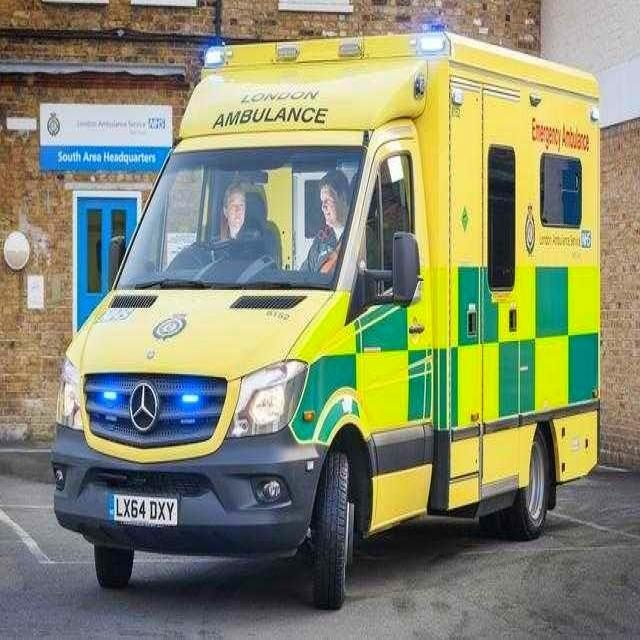

Prédiction sur ../test/images\0BNFNDX49ZWP_jpg.rf.689b59a911c79fe4bfb9c2eb4887e4b1.jpg:

image 1/1 c:\Users\CE PC\GreenFlow_Rabat\notebooks\..\test\images\0BNFNDX49ZWP_jpg.rf.689b59a911c79fe4bfb9c2eb4887e4b1.jpg: 640x640 (no detections), 135.5ms
Speed: 4.2ms preprocess, 135.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\CE PC\GreenFlow_Rabat\runs\detect\predict


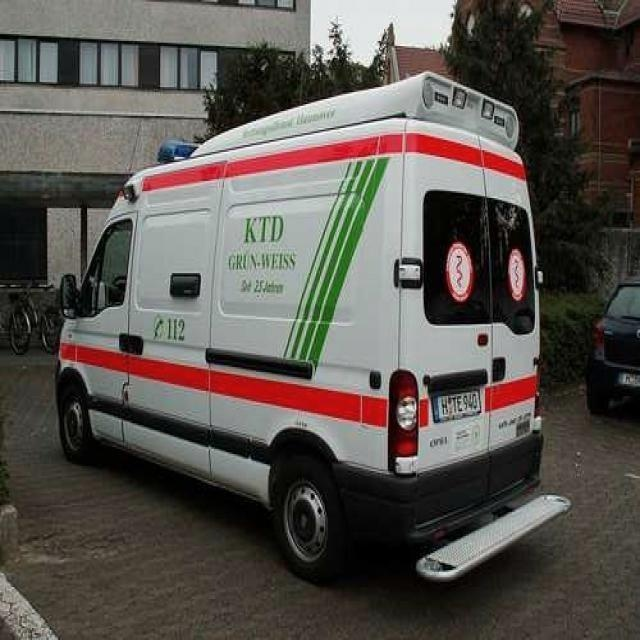

Prédiction sur ../test/images\0CS3BAJRMVRX_jpg.rf.68f55ce1e1a0682efceec970ed3d310a.jpg:

image 1/1 c:\Users\CE PC\GreenFlow_Rabat\notebooks\..\test\images\0CS3BAJRMVRX_jpg.rf.68f55ce1e1a0682efceec970ed3d310a.jpg: 640x640 (no detections), 236.8ms
Speed: 6.0ms preprocess, 236.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\CE PC\GreenFlow_Rabat\runs\detect\predict


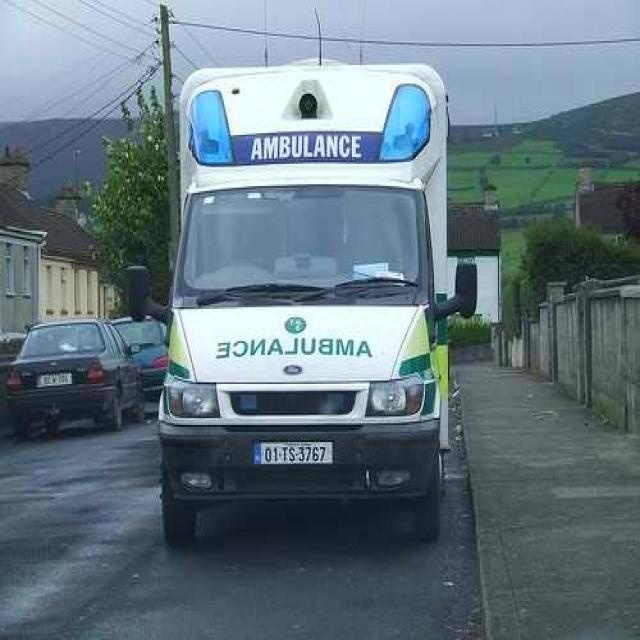

In [7]:
from ultralytics import YOLO
import glob
import os

print("--- Chargement du modèle `best.pt` pour inférence locale ---")
local_model = YOLO("../models/best.pt")

test_images = glob.glob("../test/images/*.jpg")[:3] # On teste 3 images

if not test_images:
    print("Aucune image de test trouvée ! Assurez-vous d'avoir des images dans `../test/images/`")
else:
    for image_path in test_images:
        print(f"Prédiction sur {image_path}:")
        results = local_model.predict(source=image_path, show=False, save=True, conf=0.25)
        # Montre l'image prédite dans VS Code
        try:
            display(Image(filename=results[0].save_dir + "/" + os.path.basename(image_path)))
        except Exception as e:
            print("Erreur d'affichage", e)

## Step 8: Compilation ONNX pour l'Edge (Raspberry Pi/Rock Pi)

Afin d'obtenir une fluidité optimale en temps réel sur des terminaux embarqués, PyTorch (le moteur Yolo par défaut) est trop lourd. Nous devons exporter le modèle `best.pt` au format universel et hautement optimisé **ONNX**.

In [8]:
# L'export .onnx convertit notre poids brut (Pytorch) en un graphe ultra rapide d'une centaine de Mo.
model_edge = YOLO('../models/best.pt')

try:
    print("Exportation au Format ONNX avec Opset 12 ... ")
    # Opset 12 est le plus stable et standard compatible OpenCV
    # simplify = True allège l'inférence
    path_onnx = model_edge.export(format="onnx", opset=12, simplify=True)
    
    print(f"\n✅ Succès ! Modèle de déploiement généré ici : {path_onnx}")
except Exception as e:
    print(f"La transformation onnx a échoué : {e}")
    print("Vérifiez : pip install onnx onnxruntime onnxsim")

Exportation au Format ONNX avec Opset 12 ... 
Ultralytics 8.4.21  Python-3.14.0 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,376,396 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '..\models\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.14.0 environment at: c:\Users\CE PC\GreenFlow_Rabat\venv
Resolved 12 packages in 931ms
 Downloaded onnxruntime
 Downloaded onnx
Prepared 5 packages in 19.40s
Installed 5 packages in 10.26s
 + ml-dtypes==0.5.4
 + onnx==1.20.1
 + onnxruntime==1.24.3
 + onnxslim==0.1.87
 + protobuf==7.34.0

requirements: AutoUpdate success  47.9s
WARNING requirements: Restart r

c:\Users\CE PC\GreenFlow_Rabat\venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success  55.9s, saved as '..\models\best.onnx' (9.4 MB)

Export complete (57.0s)
Results saved to C:\Users\CE PC\GreenFlow_Rabat\models
Predict:         yolo predict task=detect model=..\models\best.onnx imgsz=640 
Validate:        yolo val task=detect model=..\models\best.onnx imgsz=640 data=/kaggle/input/datasets/adamdaoudi04/greenflow/data.yaml  
Visualize:       https://netron.app

✅ Succès ! Modèle de déploiement généré ici : ..\models\best.onnx
